In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set(style='whitegrid')

In [2]:
df = pd.read_csv('../Data/winequality-red.csv', sep=';')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


### Dataset Preview

This table shows the first five records of the wine quality dataset. It includes physicochemical features such as acidity, sugar, chlorides, sulfur dioxide, pH, alcohol, and the target variable `quality`.


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [5]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

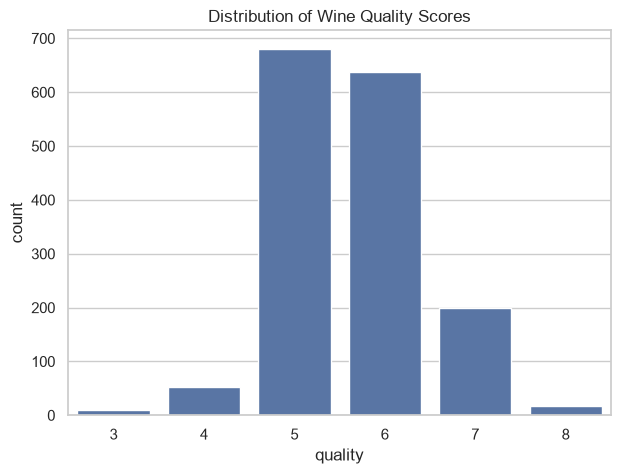

In [6]:
plt.figure(figsize=(7,5))
sns.countplot(x='quality', data=df)
plt.title('Distribution of Wine Quality Scores')
plt.savefig('../Screenshots/class_distribution.png')
plt.show()

### Distribution of Wine Quality Scores

The histogram displays the frequency of wine quality ratings. Most samples are concentrated around quality scores **5 and 6**, indicating that these are the most common wine quality levels in the dataset.


In [7]:
df['quality'].value_counts().sort_index()

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

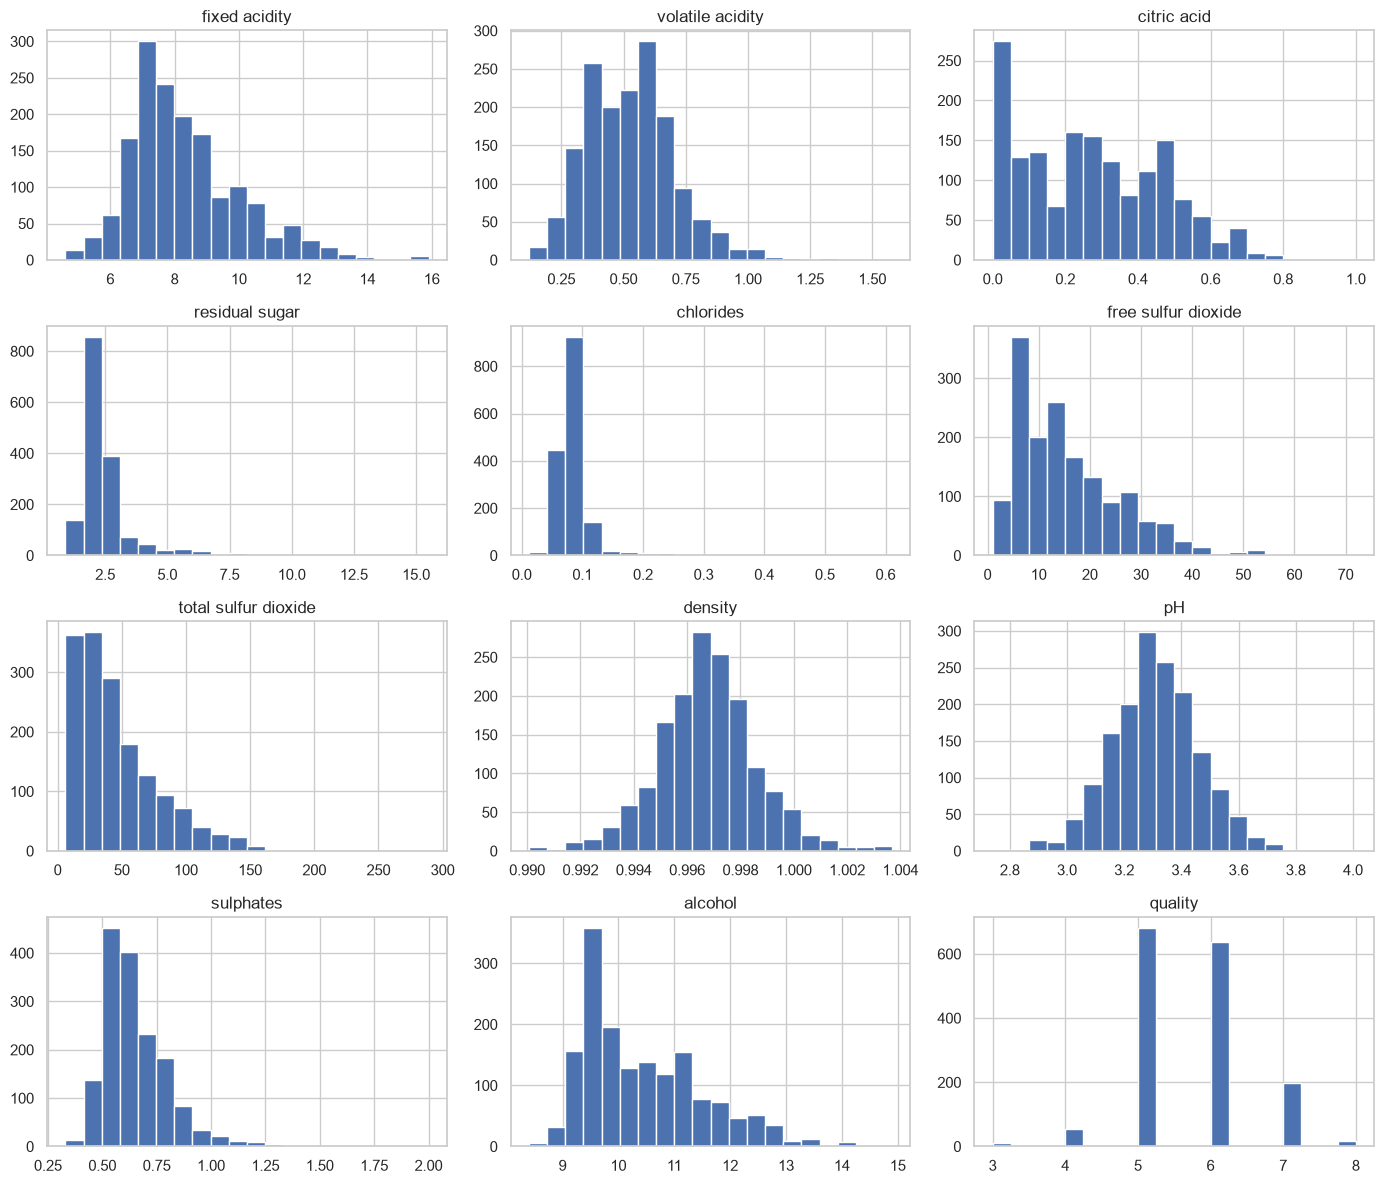

In [8]:
df.hist(figsize=(14,12), bins=20)
plt.tight_layout()
plt.show()

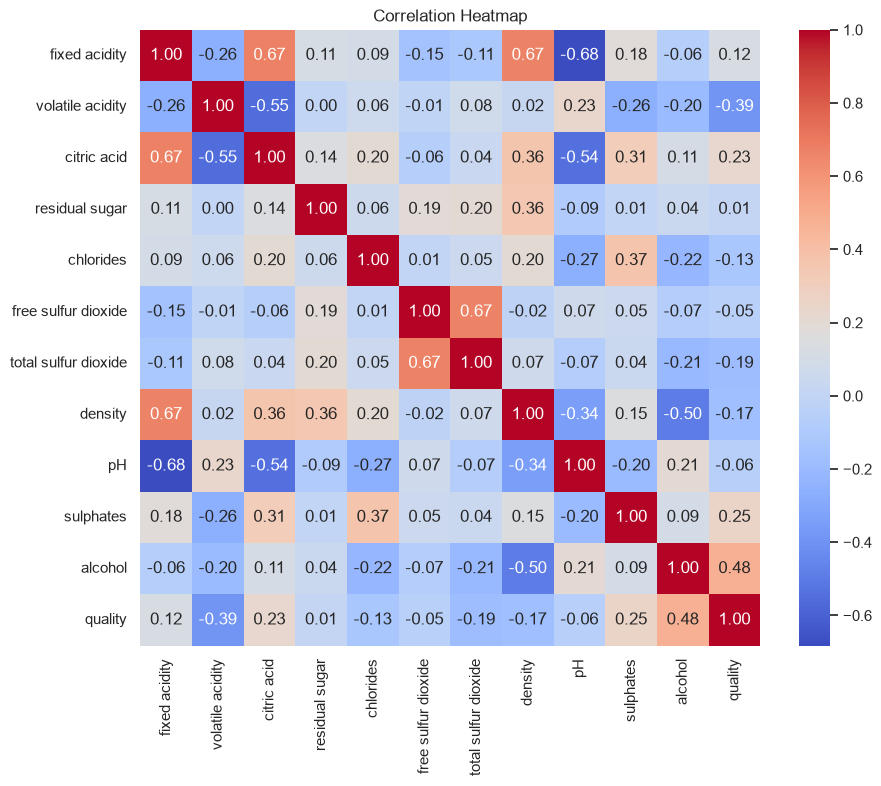

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('../Screenshots/correlation_heatmap.png')
plt.show()

### Correlation Heatmap

The heatmap illustrates the correlation between all numerical features. It helps identify positive and negative relationships, with **alcohol** showing a positive correlation with wine quality and **volatile acidity** showing a negative correlation.


In [10]:
df['quality_binary'] = np.where(df['quality'] >= 7, 1, 0)

df['quality_binary'].value_counts()

quality_binary
0    1382
1     217
Name: count, dtype: int64

In [11]:
X = df.drop(['quality', 'quality_binary'], axis=1)
y = df['quality_binary']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print('Random Forest Accuracy:', rf_accuracy)
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.94375
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       277
           1       0.93      0.63      0.75        43

    accuracy                           0.94       320
   macro avg       0.94      0.81      0.86       320
weighted avg       0.94      0.94      0.94       320



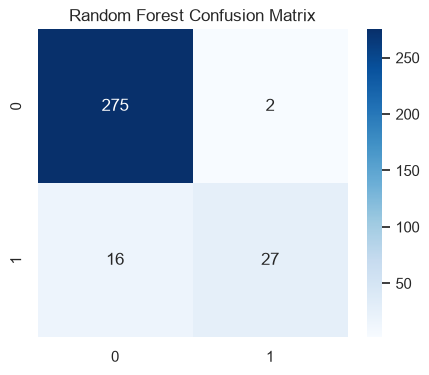

In [14]:
cm_rf = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.savefig('../Screenshots/confusion_matrix_rf.png')
plt.show()

### Random Forest Confusion Matrix

The confusion matrix shows the performance of the Random Forest classifier. The model correctly classified **275 negative samples** and **27 positive samples**, while making **2 false positives** and **16 false negatives**. This indicates that the model achieved strong overall classification performance with relatively few prediction errors.


In [15]:
sgd = SGDClassifier(random_state=42)

sgd.fit(X_train, y_train)

sgd_pred = sgd.predict(X_test)

sgd_accuracy = accuracy_score(y_test, sgd_pred)

print('SGD Accuracy:', sgd_accuracy)
print(classification_report(y_test, sgd_pred))

SGD Accuracy: 0.675
              precision    recall  f1-score   support

           0       0.97      0.65      0.77       277
           1       0.27      0.86      0.42        43

    accuracy                           0.68       320
   macro avg       0.62      0.75      0.60       320
weighted avg       0.87      0.68      0.73       320



In [16]:
svc = SVC(kernel='rbf', random_state=42)

svc.fit(X_train, y_train)

svc_pred = svc.predict(X_test)

svc_accuracy = accuracy_score(y_test, svc_pred)

print('SVC Accuracy:', svc_accuracy)
print(classification_report(y_test, svc_pred))

SVC Accuracy: 0.865625
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       277
           1       0.00      0.00      0.00        43

    accuracy                           0.87       320
   macro avg       0.43      0.50      0.46       320
weighted avg       0.75      0.87      0.80       320



c:\OIBSIP\DataAnalytics-L2-WineQualityPrediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\OIBSIP\DataAnalytics-L2-WineQualityPrediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\OIBSIP\DataAnalytics-L2-WineQualityPrediction\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

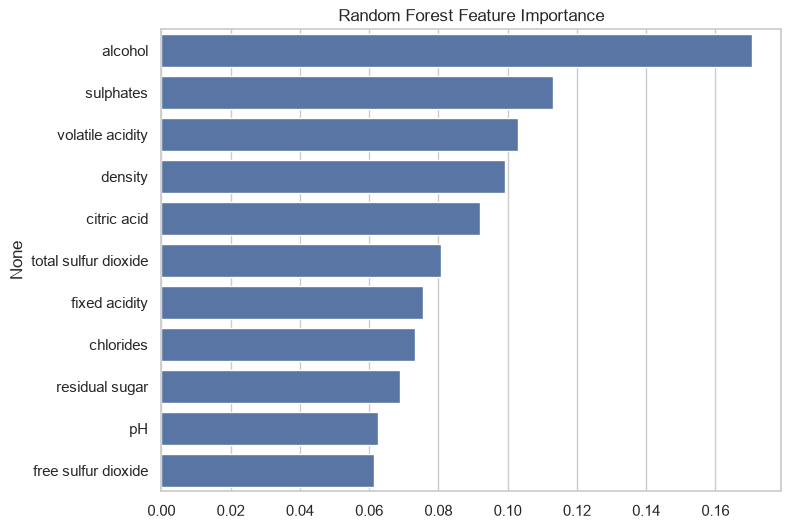

In [17]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=importance.values, y=importance.index)
plt.title('Random Forest Feature Importance')
plt.savefig('../Screenshots/feature_importance.png')
plt.show()

### Random Forest Feature Importance

This bar chart shows the importance of each feature in the Random Forest model. **Alcohol** is the most influential feature for predicting wine quality, followed by **sulphates**, **volatile acidity**, and **density**. Features with higher importance contribute more to the model’s predictions.


In [18]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'SGD Classifier', 'Support Vector Classifier'],
    'Accuracy': [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]
})

results = results.sort_values(
    by='Accuracy',
    ascending=False
)

results

,Model,Accuracy
0,Random Forest,0.943750
2,Support Vector Classifier,0.865625
1,SGD Classifier,0.675000


### Model Accuracy Comparison

This table compares the performance of different machine learning models. **Random Forest** achieved the highest accuracy (**94.38%**), followed by **Support Vector Classifier (86.56%)**, while **SGD Classifier** showed the lowest accuracy (**67.50%**). Random Forest performed best for the wine quality prediction task.


## Summary

The **Wine Quality Prediction** project aimed to classify wine quality based on its physicochemical properties using machine learning techniques. The dataset was explored through data inspection, distribution analysis, and correlation analysis to understand feature relationships and quality patterns.

Multiple classification models were trained and evaluated, including **Random Forest**, **Support Vector Classifier (SVC)**, and **SGD Classifier**. Among these, the **Random Forest model achieved the highest accuracy of 94.38%**, making it the best-performing model for this task. The confusion matrix showed that the model correctly classified most wine samples with very few prediction errors.

Feature importance analysis revealed that **alcohol**, **sulphates**, **volatile acidity**, and **density** were the most influential factors in predicting wine quality. Overall, the project demonstrates the complete workflow of a machine learning classification problem, including **data preprocessing, exploratory data analysis (EDA), model training, evaluation, and interpretation of results**.
